In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
from parsing_lib import frame_and_muid, populate_dict, populate_dict_panda, calculate_unique_message_id, iterative_intersect
from parsing_lib import return_all_messages_for_frame, return_all_frames_messages_for_muid_and_frame, clean_bad_timestamps
from parsing_lib import return_frame_IDs_with_message_changes, return_frame_IDs_muids, return_unique_messages_for_frame
from parsing_lib import return_frame_IDs_muids_with_message_changes_in_timestamp_range, return_interesting_timestamps

In [9]:
offon_101_010_1_0 = {}
offon_010101 = {}
on = {}
off = {}
ref = {}

In [4]:
%ls -tr /home/trh/Documents/SavvyCAN\ logs/

 M-CAN_nothing_happening.csv
 M-CAN_climate_on.csv
 M-CAN_climate_on_defrost.csv
 M-CAN_remote_climate_62F_warmers_on.csv
 M-CAN_maybe_captured_preconditioning.csv
 M-CAN_definitely_captured_preconditioning_at_end.csv
 M-CAN_driving_with_nav_no_preconditioning.csv
 M-CAN_left_seat_warmer_only.csv
 M-CAN_steering_wheel_warmer_only.csv
 M-CAN_right_seat_warmer_only.csv
 M-CAN_climate_on_more_isolated.csv
 M-CAN_rear_defrost_on.csv
 M-CAN_stopped_in_D_nav_on_preconditioning_already_on.csv
 M-CAN_driving_with_nav_no_preconditioning_2.csv
 M-CAN_stopped_in_D_cancelling_nav_and_preconditioning.csv
 M-CAN_driving_maybe_captured_preconditioning.csv
 M-CAN_driving_with_nav_captured_preconditioning.csv
 M-CAN_stopped_in_D_cancelling_nav_and_preconditioning_2.csv
 M-CAN_driving_with_nav_to_school_no_preconditioning.csv
 M-CAN_driving_with_nav_to_school_no_preconditioning_including_reroute.csv
 M-CAN_driving_with_nav_to_charger_no_preconditioning.csv
 M-CAN_parked_in_D_navigating_to_charger.csv
 M

In [10]:
populate_dict(offon_101_010_1_0, '/home/trh/Documents/SavvyCAN logs/M-CAN_MITM_off-on-off_on-off-on_off_on_brake_in.csv')
populate_dict(offon_010101, '/home/trh/Documents/SavvyCAN logs/M-CAN_MITM_off-on-off-on-off-on_brake_in.csv')
populate_dict(off, '/home/trh/Documents/SavvyCAN logs/M-CAN_MITM_off_no_brake.csv')
populate_dict(on, '/home/trh/Documents/SavvyCAN logs/M-CAN_MITM_on_no_brake.csv')
populate_dict(ref, '/home/trh/Documents/SavvyCAN logs/M-CAN_MITM_ill_bing.csv')

In [11]:
all_logs = [
    offon_101_010_1_0,
    offon_010101,
    off,
    on,
    ref
]
for log in all_logs:
    clean_bad_timestamps(log)
    calculate_unique_message_id(log)

Identified 1 drops in timestamp and 3241 total timestamp jumps.
Identified 1 drops in timestamp and 1637 total timestamp jumps.
Identified 1 drops in timestamp and 819 total timestamp jumps.
Identified 1 drops in timestamp and 603 total timestamp jumps.
Identified 1 drops in timestamp and 1253 total timestamp jumps.


In [12]:
offon_010101_ids_muids = return_frame_IDs_muids(offon_010101)
offon_101_010_1_0_ids_muids = return_frame_IDs_muids(offon_101_010_1_0)
off_muids = return_frame_IDs_muids(off)
on_muids = return_frame_IDs_muids(on)

In [23]:
log = offon_101_010_1_0
press_timestamps = log['timestamps'][(log['messages'][:,0] == 9)*(log['ids'] == int('39',16))]
press_ranges = [[timestamp-500000,timestamp+500000] for timestamp in press_timestamps]
# return_all_messages_for_frame(log,int('253',16))

In [24]:
for timestamp in press_timestamps:
    print(timestamp)

2847215
2897071
2947289
2997168
9789583
9839208
9890019
9939225
12531590
12581416
12631862
20523959
20575280
20624376
20674735


In [27]:
change_ids_muids = []
# for press_range in press_ranges:
    # change_ids_muids.append(return_frame_IDs_muids_with_message_changes_in_timestamp_range(log,press_range, threshold=3, only_within_range=False))
    # for frame_id_muid in change_ids_muids[-1]:
    #     print(frame_id_muid.frame_id)
# all_change_ids_muids = iterative_intersect(change_ids_muids)
change_ids_muids.append(return_frame_IDs_muids_with_message_changes_in_timestamp_range(log,[log['timestamps'][0],log['timestamps'][-1]], threshold=4, only_within_range=False))
press_range = press_ranges[0]
# change_ids_muids.append(return_frame_IDs_muids_with_message_changes_in_timestamp_range(log,press_range, threshold=3, only_within_range=False))
for frame_id_muid in change_ids_muids[-1]:
    print(frame_id_muid.frame_id)
all_change_ids_muids = change_ids_muids[0]
all_change_ids = np.unique([change_id_muid.frame_id for change_id_muid in all_change_ids_muids])

57
57
98
98
98
100
100
199
199
199
292
292
292
338
338
354
354
413
413
413
414
414
414
418
418
419
419
487
487
503
503
503
504
504
505
505
509
509
551
551
551
568
568
604
604
604
696
696
727
727
728
728
767
767
767
780
780
781
781
781
808
808
809
809
818
818
820
820
896
896
898
898
898
899
899
930
930
942
942
945
945
1040
1040
1040
1041
1041
1045
1045
1045
1066
1066
1066
1224
1224
1245
1245
1255
1255
1302
1302
1302
1379
1379
1379
1381
1381
1381
1382
1382
1584
1584
1585
1585
1586
1586
1587
1587
1588
1588
1589
1589
1590
1590
1591
1591
1593
1593


In [ ]:
# return_unique_messages_for_frame(log,int('39',16))
for message in return_all_messages_for_frame(log,int('39',16)):
    print(message)

0x39
0x62
0x64
0xc7
0x124


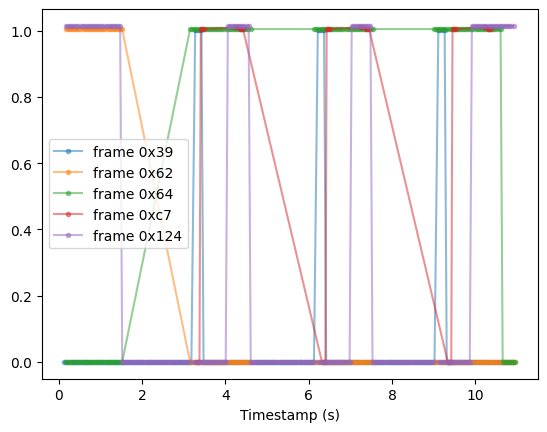

0x152
0x162
0x19d
0x19e
0x1a2


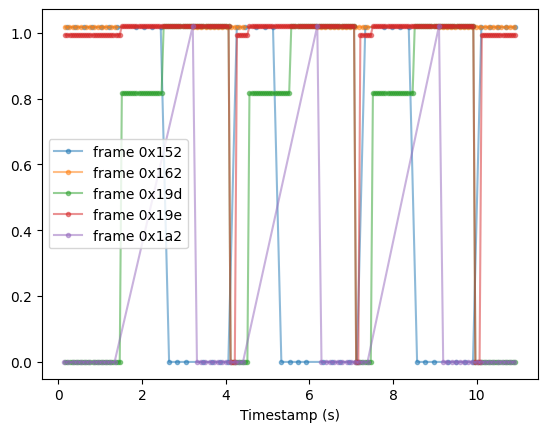

0x1a3
0x1e7
0x1f7
0x1f8
0x1f9


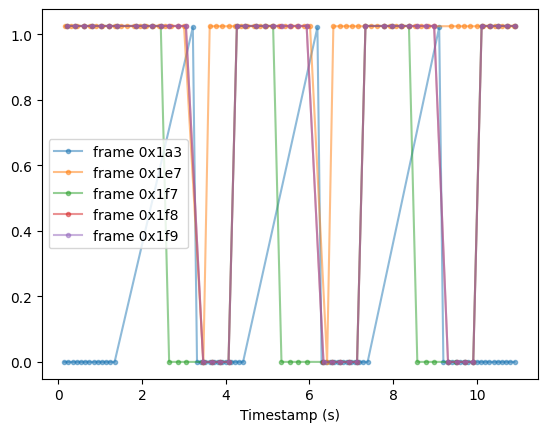

0x1fd
0x227
0x238
0x25c
0x2b8


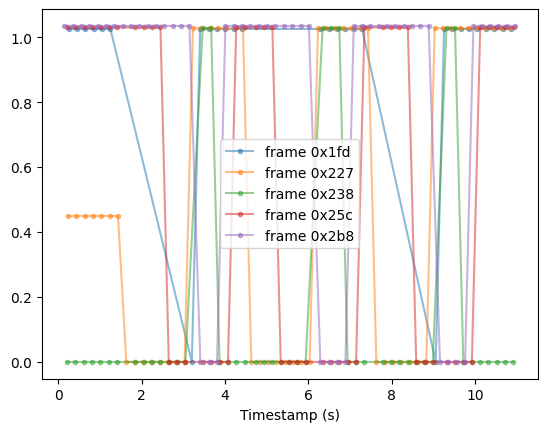

0x2d7
0x2d8
0x2ff
0x30c
0x30d


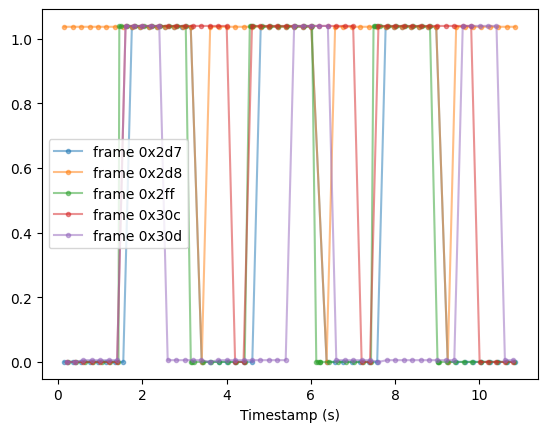

0x328
0x329
0x332
0x334
0x380


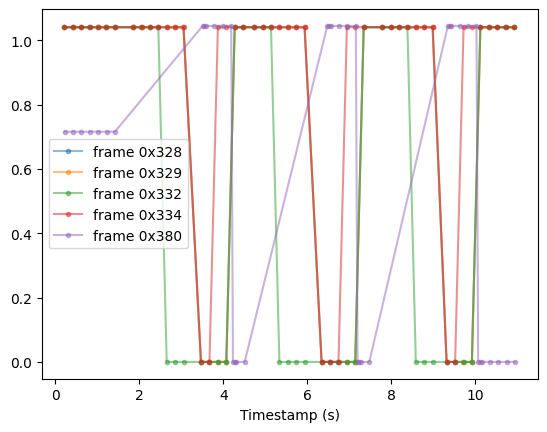

0x382
0x383
0x3a2
0x3ae
0x3b1


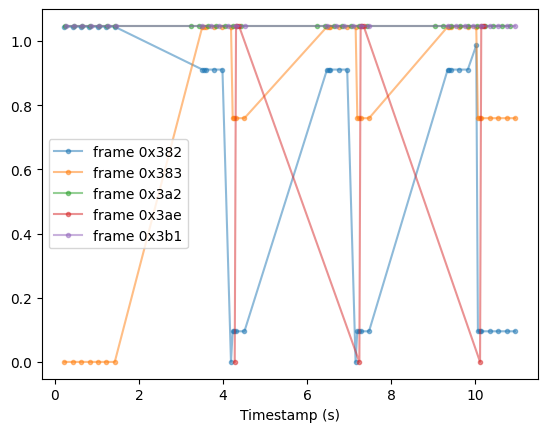

0x410
0x411
0x415
0x42a
0x4c8


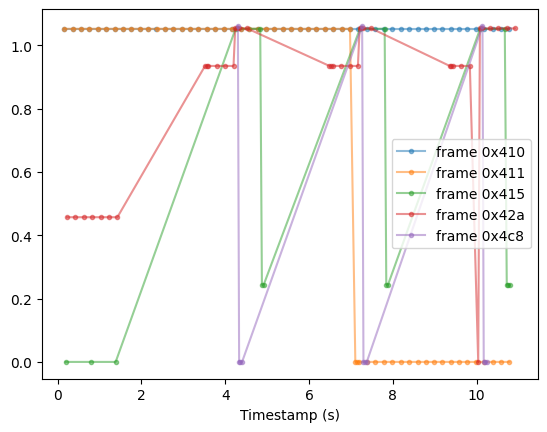

0x4dd
0x4e7
0x516
0x563
0x565


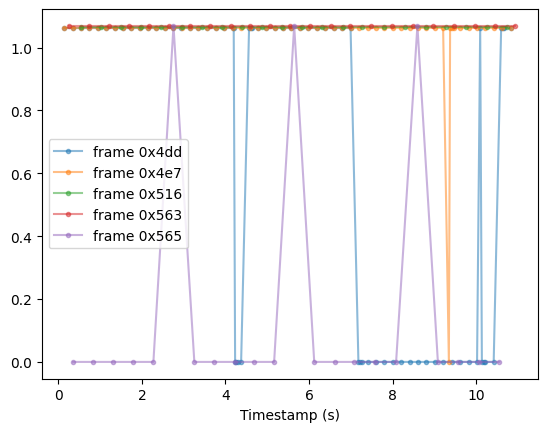

0x566
0x630
0x631
0x632
0x633


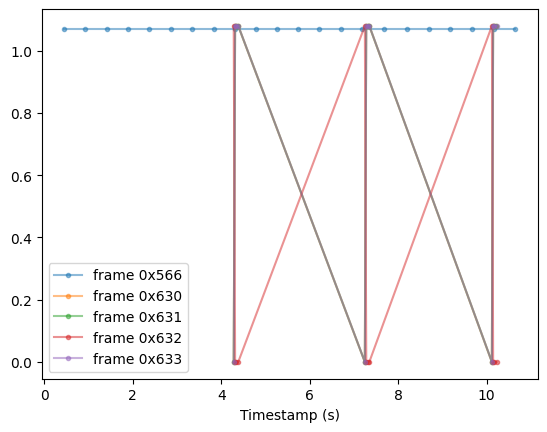

0x634
0x635
0x636
0x637
0x639


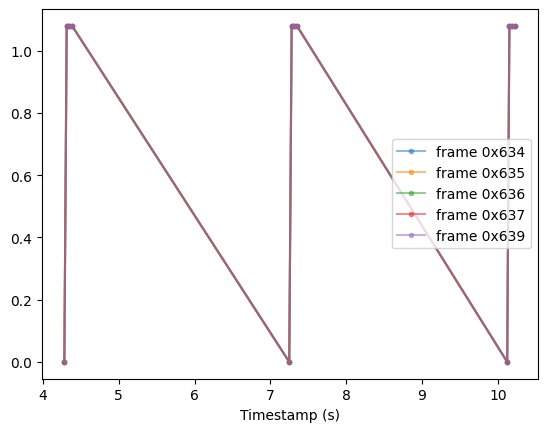

/tmp/ipykernel_264712/596454399.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


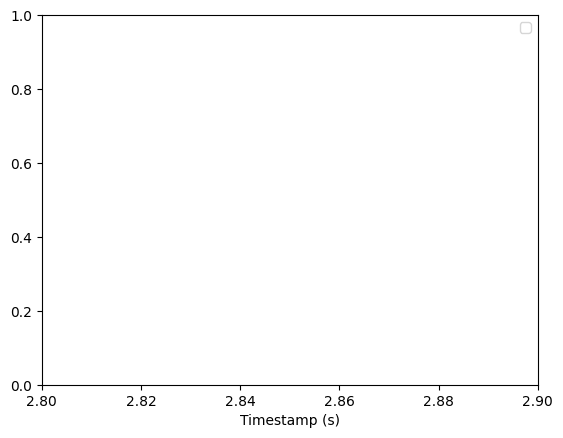

In [41]:
log = offon_010101
for i,frame_id in enumerate(all_change_ids):
# for i,frame_id in enumerate(ids_to_check):
    print(hex(frame_id))
    indices = np.argwhere(log['ids'] == frame_id)[:,0]
    if(len(indices)):
        norm_vals = log['messages_unique_ids'][indices].astype(float)
        if(norm_vals.min() != norm_vals.max()):
            norm_vals -= norm_vals.min()
        norm_vals += 1e-6
        norm_vals /= norm_vals.max()
        norm_vals *= 1+(0.05*frame_id/1000)
        plt.plot(log['timestamps'][indices]/1e6,norm_vals,label=f'frame {hex(frame_id)}', alpha=0.5, marker='.', linestyle=None)
    if(i % 5 == 4):
        plt.xlabel('Timestamp (s)')
        # plt.xlim([2.0,2.9])
        plt.legend()
        plt.show()

plt.xlabel('Timestamp (s)')
# plt.xlim([2.0,2.9])
plt.legend()
plt.show()